In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

## Configuration

In [2]:
DB_DIR = "../example_data"

PATTERN_MATCHES_DB = f"{DB_DIR}/pattern_matches.db"
TRANSACTION_DB = f"{DB_DIR}/transactions.db"
TRANSACTION_HEAD = "transaction_head"
TRANSACTIONS_OBL_ACTOR_LOC_COUNTS = "trans_obl_actor_loc_counts"
TRANSACTIONS_OBL_LOC = "trans_obl_loc"

#or alternatively for original data
GRAPH_DATA_DIR = "graph_data_files/"
ORIGINAL_ROOT_COUNT_FILE = f"{GRAPH_DATA_DIR}verb_root_live_nonlive_counts_wrole.csv"
SUBSET_FILE = f"{GRAPH_DATA_DIR}verb_root_live_nonlive_counts_wrole_subset_examples.csv.csv"

## Connect to db

In [3]:
con = sqlite3.connect(PATTERN_MATCHES_DB)
cur = con.cursor()
cur.execute(f'ATTACH DATABASE "{TRANSACTION_DB}" AS trans')

## Read in data

In [35]:
#query = """SELECT * from {tbl}""".format(tbl=TRANSACTIONS_OBL_ACTOR_LOC_COUNTS)
#source = pd.read_sql_query(query, con)
#source

Or alternatively

In [9]:
source = pd.read_csv(ORIGINAL_ROOT_COUNT_FILE, sep=",", encoding="utf-8")
source = source.fillna("")
source

,verb,verb_compound,kaane,elus_cnt,mitteelus_cnt,root_cnt,isik,total
0,saama,,el,1274,402,19632,vahel,1676
1,andma,,all,1601,250,11612,vahel,1851
2,rääkima,,el,802,202,10891,vahel,1004
3,saama,,in,134,306,8532,mitte kunagi,440
4,tulema,,ad,1134,166,8468,alati,1300
...,...,...,...,...,...,...,...,...
74715,šveitsima,,el,0,0,1,,0
74716,švipsima,,ad,0,0,1,,0
74717,žestikuleerima,,ad,0,1,1,,1
74718,žisraelima,,ad,0,0,1,,0


## Workflow

In [ ]:
source["total"] = source["elus_cnt"] + source["mitteelus_cnt"]

Lisa root sõnade näiteid. (Kuna näite tabelis on ainult obl ja väike hulk näiteid siis igale verbile ei pruugi olla 3 näidet)

In [78]:
ex1 = []

for i in tqdm(range(len(source))):
    verb = source.iloc[i]["verb"]
    comp = source.iloc[i]["verb_compound"]
    kaane = source.iloc[i]["kaane"]
    res = cur.execute("""SELECT root_form from {tbl}
    where verb = '{V}' and verb_compound = '{VC}' and loc_case='{C}' 
    limit 3
    """.format(tbl=TRANSACTIONS_OBL_LOC, V=verb, VC=comp, C=kaane))

    exs = ",".join(list(set([e[0].lower() for e in res])))
    ex1.append(exs)

100%|███████████████████████████████████| 74720/74720 [00:27<00:00, 2701.26it/s]


In [80]:
source["examples"] = ex1

In [81]:
source["elus_div"] = source["elus_cnt"]/source["root_cnt"]
source["mitteelus_div"] = source["mitteelus_cnt"]/source["root_cnt"]

In [82]:
source

,verb,verb_compound,kaane,elus_cnt,mitteelus_cnt,root_cnt,isik,total,examples,elus_div,mitteelus_div
0,saama,,el,1274,402,19632,vahel,1676,"inimestest,toidupoest,sõnadest",0.064894,0.020477
1,andma,,all,1601,250,11612,vahel,1851,meile,0.137875,0.021529
2,rääkima,,el,802,202,10891,vahel,1004,"seksuaalulmadest,mõrvadest",0.073639,0.018547
3,saama,,in,134,306,8532,mitte kunagi,440,"oktoobris,koolipingis",0.015706,0.035865
4,tulema,,ad,1134,166,8468,alati,1300,"sul,linnal,neil",0.133916,0.019603
...,...,...,...,...,...,...,...,...,...,...,...
74715,šveitsima,,el,0,0,1,,0,,0.000000,0.000000
74716,švipsima,,ad,0,0,1,,0,,0.000000,0.000000
74717,žestikuleerima,,ad,0,1,1,,1,,0.000000,1.000000
74718,žisraelima,,ad,0,0,1,,0,,0.000000,0.000000


In [42]:
areadict = {}
root_cnts = sorted(list(set(list(source["total"])))) 

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 5
    elif cnt >=10 and cnt < 100: areadict[cnt] = 10
    elif cnt >=100 and cnt < 1000: areadict[cnt] = 30
    #elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 5000: areadict[cnt] = 50
    #elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 20000: areadict[cnt] = 80
    #elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=20000 and cnt < 50000: areadict[cnt] = 100
    elif cnt >=50000: areadict[cnt] = 200

# TAVAPLOT

### normaliseeritud väärtustega pilt, filtreerib root_cnt ja total

In [83]:
source3 = source[source["total"]>0]
source4 = source3[source3["root_cnt"]>=1000]
source4 = source4[source4["total"]>=700]

In [84]:
roots = list(source4["total"])
kohad =  list(source4["mitteelus_div"])
elusad = list(source4["elus_div"])

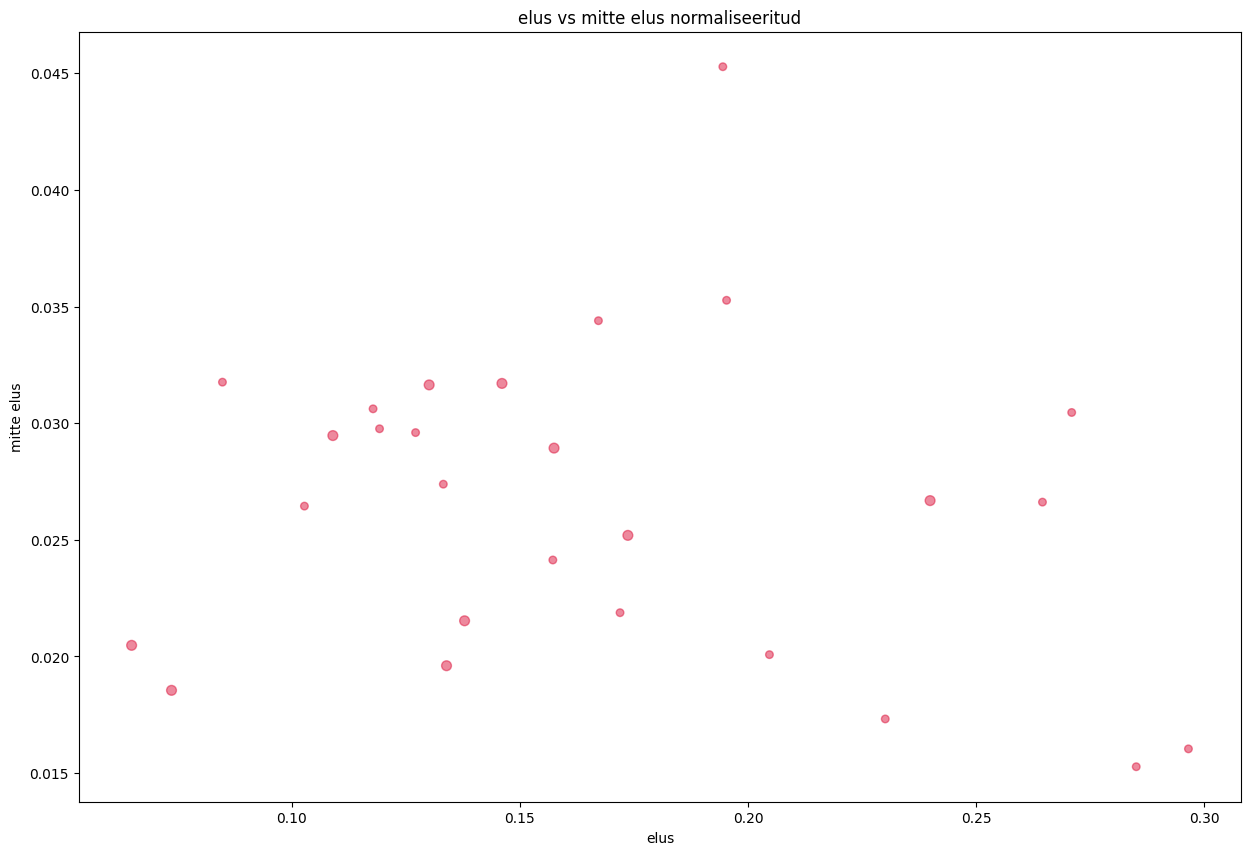

In [85]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs mitte elus normaliseeritud")
plt.ylabel("mitte elus")
plt.xlabel("elus")

plt.show()

# HOVER

In [88]:
#source4.to_csv(SUBSET_FILE,sep=";", encoding="utf-8", index=False)

In [24]:
source4 = pd.read_csv(SUBSET_FILE, sep=";", encoding="utf-8")
source4 = source4.fillna("")
source4["data"] = source4['verb']+ source4['verb_compound']+" (" +source4['kaane']+") " +source4['examples']

In [25]:
source4

,verb,verb_compound,kaane,elus_cnt,mitteelus_cnt,root_cnt,isik,total,examples,elus_div,mitteelus_div,data
0,saama,,el,1274,402,19632,vahel,1676,"inimestest,toidupoest,sõnadest",0.064894,0.020477,"saama (el) inimestest,toidupoest,sõnadest"
1,andma,,all,1601,250,11612,vahel,1851,meile,0.137875,0.021529,andma (all) meile
2,rääkima,,el,802,202,10891,vahel,1004,"seksuaalulmadest,mõrvadest",0.073639,0.018547,"rääkima (el) seksuaalulmadest,mõrvadest"
3,tulema,,ad,1134,166,8468,alati,1300,"sul,linnal,neil",0.133916,0.019603,"tulema (ad) sul,linnal,neil"
4,minema,,all,810,219,7431,vahel,1029,"mulle,luurele",0.109003,0.029471,"minema (all) mulle,luurele"
5,tegema,,all,1143,210,7258,vahel,1353,,0.157481,0.028934,tegema (all)
6,tulema,,all,847,206,6510,vahel,1053,kontserdile,0.130108,0.031644,tulema (all) kontserdile
7,jääma,,all,949,206,6497,vahel,1155,,0.146067,0.031707,jääma (all)
8,jääma,,el,534,200,6297,mitte kunagi,734,,0.084802,0.031761,jääma (el)
9,tegema,,el,579,149,5634,mitte kunagi,728,"mehest,prantslasest",0.102769,0.026447,"tegema (el) mehest,prantslasest"


In [27]:
fig = px.scatter(source4, x='elus_div', y='mitteelus_div', hover_name="data")#, text=source4['verb'])#+ source4['verb_compound']+" (" +source4['kaane']+") " +source4['examples'])

# Update the layout to show the text on hover
#fig.update_traces(#marker=dict(size=12),
#selector=dict(mode='markers'),
#selector=dict(type='scatter'),
#hoverinfo='none',
#)
#fig.update_traces(
#hoverinfo='text',
#hovertext="banaan", #source4['verb']+ source4['verb_compound']+" (" +source4['kaane']+") " +source4['examples']
#)

fig.update_layout(hovermode='closest')
fig.write_html("verb_elus_vs_mitteelus.html")
fig.show()

In [28]:
fig = px.scatter(source4, x='elus_cnt', y='mitteelus_cnt', hover_name="data")#, text=source4['verb'])#+ source4['verb_compound']+" (" +source4['kaane']+") " +source4['examples'])

# Update the layout to show the text on hover
#fig.update_traces(#marker=dict(size=12),
#selector=dict(mode='markers'),
#selector=dict(type='scatter'),
#hoverinfo='none',
#)
#fig.update_traces(
#hoverinfo='text',
#hovertext="banaan", #source4['verb']+ source4['verb_compound']+" (" +source4['kaane']+") " +source4['examples']
#)

fig.update_layout(hovermode='closest')
fig.write_html("verb_elus_vs_mitteelus2.html")
fig.show()

In [98]:
con.close()